# Introduction to Age Regression Using the UTKFace Dataset
In this project, we explore age regresio using the UTKFace dataset, which contains facial images annotated with age information. The dataset is composed of diverse images of individuals, allowing for robust training of a convolutional neural network (CNN) model. We employ a sequential model comprising multiple convolutional layers followed by pooling layers, leading to a dense output layer for regression. The model is trained on the features extracted from the images, with the goal of accurately predicting the age of individuals based on their facial features.


In [20]:
# pip install --upgrade jupyter ipywidgets

In [21]:
# pip install --upgrade scikit-learn

In [22]:
# pip install ipywidgets

In [23]:
# pip install kagglehub

In [24]:
# pip install tqdm

In [25]:
# pip install seaborn

### Importing Libraries
This section imports the necessary libraries for data manipulation, visualization, and building a convolutional neural network model. Key libraries include NumPy for numerical operations, Pandas for data handling, Matplotlib and Seaborn for plotting, and TensorFlow/Keras for deep learning.

In [26]:
# System utilities and warnings
import os
import random

# Data manipulation and processing
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar for loops
from tqdm import tqdm

# TensorFlow and Keras for building neural networks
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Dropout, MaxPooling2D, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Keras for metrics
from keras.metrics import RootMeanSquaredError
from keras.models import Model

# Scikit Learn for split test data and train data
from sklearn.model_selection import train_test_split

# Image processing
from PIL import Image

# Kaggle dataset access
import kagglehub

### Downloading the Dataset
This section downloads the latest version of the 'utkface-new' dataset from Kaggle Hub and prints the file path to confirm that the download was successful.

In [27]:
# Download the latest version of the 'utkface-new' dataset from Kaggle Hub
path = kagglehub.dataset_download("jangedoo/utkface-new")

# Print the dataset file path to verify successful download
print(f"Path to dataset files: {path}")

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\jangedoo\utkface-new\versions\1


### Extracting Image Paths and Age Labels
This section initializes empty lists to store image paths and age labels. It iterates through the filenames in the specified directory, constructs the full image paths, and extracts the age information from the filenames.

In [28]:
# Define the base directory for the UTKFace dataset images
BASE_DIR = "C:/Users/USER/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/UTKFace"

In [29]:
# Initialize empty lists for image paths and age labels
image_paths = []
age_labels = []

# Iterate over filenames in the BASE_DIR, using tqdm for a progress bar
for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)  # Create full image path
    temp = filename.split("_")  # Split filename to extract metadata

    age = int(temp[0])  # Extract age from the second element

    image_paths.append(image_path)  # Store the image path
    age_labels.append(age)  # Store the age label

100%|██████████| 23708/23708 [00:00<00:00, 884865.76it/s]


### Creating a DataFrame for Image Data
This section creates an empty DataFrame using Pandas and assigns the previously extracted image paths and age labels to it. Finally, it displays the resulting DataFrame containing the image paths and their corresponding age labels.

In [30]:
# Create an empty DataFrame using pandas
data = pd.DataFrame()

# Assign image paths and age labels to the DataFrame
data["image"], data["age"] = image_paths, age_labels

# Display the resulting DataFrame
data

,image,age
0,C:/Users/USER/.cache/kagglehub/datasets/janged...,100
1,C:/Users/USER/.cache/kagglehub/datasets/janged...,100
2,C:/Users/USER/.cache/kagglehub/datasets/janged...,100
3,C:/Users/USER/.cache/kagglehub/datasets/janged...,100
4,C:/Users/USER/.cache/kagglehub/datasets/janged...,100
...,...,...
23703,C:/Users/USER/.cache/kagglehub/datasets/janged...,9
23704,C:/Users/USER/.cache/kagglehub/datasets/janged...,9
23705,C:/Users/USER/.cache/kagglehub/datasets/janged...,9
23706,C:/Users/USER/.cache/kagglehub/datasets/janged...,9


### Displaying Sample Images with Age Labels
This section creates a grid of images from the DataFrame, displaying the first 25 samples. It uses a dictionary to map age indices to readable labels and presents each image along with its corresponding age label in a 5x5 subplot.

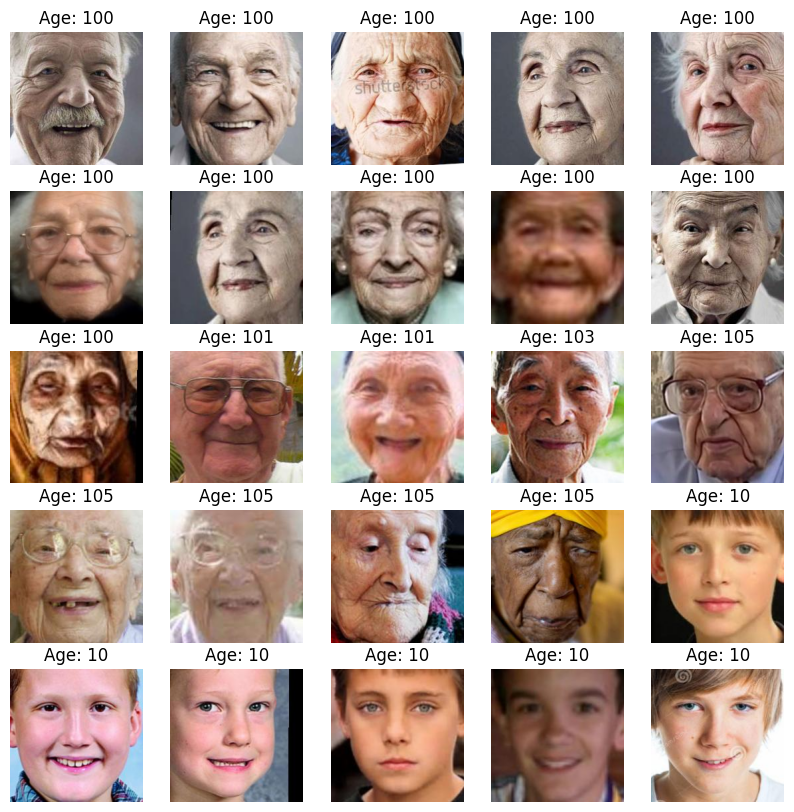

In [31]:
# Set figure size to display a grid of images
plt.figure(figsize=(10, 10))

# Select the first 25 rows of the DataFrame "data" for visualization
files = data.iloc[0:25]

# Iterate through selected rows using itertuples to access indices and columns
for index, file, age in files.itertuples():
    plt.subplot(5, 5, index + 1)  # Create a 5x5 subplot grid for each image

    img = load_img(file)  # Load the image
    img = np.array(img)  # Convert the image to a NumPy array

    plt.imshow(img)  # Display the image in the subplot

    plt.title(f"Age: {age}")  # Set title with corresponding age label

    plt.axis("off")  # Turn off axis labels and ticks

### Feature Extraction from Images
This function extracts features from a list of images by loading them in grayscale, resizing them to 128x128 pixels, and converting them into a NumPy array. The processed images are stored in a list, which is then reshaped to fit the model's input requirements before returning the final feature array.

In [32]:
def extract_features(images):
    features = []  # Initialize an empty list to store features

    # Iterate through the image list with a progress bar
    for image in tqdm(images):
        img = load_img(image, color_mode="grayscale")  # Load the image in grayscale
        img = img.resize((198, 198))  # Resize the image to 198x198 pixels
        img = np.array(img)  # Convert image to a NumPy array

        features.append(img)  # Add the processed image to the features list

    # Convert the list to a NumPy array
    features = np.array(features)

    # Reshape the array to (number of images, 198x198, 1 channel)
    features = features.reshape(len(features), 198, 198, 1)

    return features  # Return the final feature array

### Extraction and Train-Test Split
This code snippet extracts image features and prepares the dataset for training by splitting it into training and testing sets.

In [33]:
# Extract image features from the 'image' column in 'data'
X = extract_features(data["image"])

# Convert the 'age' column into a NumPy array
y = np.array(data["age"])

# Split the data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the input data (pixel values will be between 0 and 1)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

100%|██████████| 23708/23708 [00:13<00:00, 1799.42it/s]


### Defining and Compiling the Convolutional Neural Network Model
This code snippet defines a convolutional neural network (CNN) model using Keras. It includes multiple convolutional layers followed by pooling layers, and compiles the model with a specified loss function, optimizer, and evaluation metrics.

In [34]:
# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor="val_loss",  # Monitor validation loss
    patience=3,  # Stop training after 3 epochs with no improvement
    restore_best_weights=True  # Restore the best model weights
)

# Define the sequential model for regression
model = Sequential([
    Input(shape=(198, 198, 1)),  # Input layer with shape (198, 198, 1)
    Conv2D(32, (3, 3),strides=3, padding='same', activation="relu"),  # First convolutional layer
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.2),  # Dropout to prevent overfitting

    Conv2D(32, (3, 3),strides=2, padding='same', activation="relu"),  # Second convolutional layer
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.2),  # Dropout to prevent overfitting

    Conv2D(64, (3, 3),strides=2, padding='same', activation="relu"),  # Third convolutional layer
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.2),  # Dropout to prevent overfitting

    Conv2D(128, (3, 3),strides=2, padding='same', activation="relu"),  # Fourth convolutional layer
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.4),  # Dropout to prevent overfitting


    Flatten(),  # Flatten the output for the dense layer
    
    Dense(512, activation="relu"),  # Fully connected layer with 512 neurons
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.5),  # Dropout to prevent overfitting
    
    Dense(256, activation="relu"),  # Fully connected layer with 256 neurons
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.45),  # Dropout to prevent overfitting
    
    Dense(128, activation="relu"),  # Fully connected layer with 128 neurons
    BatchNormalization(axis=-1),  # Batch normalization layer
    Dropout(0.4),  # Dropout to prevent overfitting
    
    Dense(1)  # Output layer for regression (no activation needed)
])

# Compile the model for regression
model.compile(
    loss="mean_squared_error",  # Loss function for regression
    optimizer=Adam(learning_rate=0.0001),  # Adam optimizer
    metrics=[RootMeanSquaredError()]  # RMSE as evaluation metric
)

### Training the Convolutional Neural Network Model
This code snippet trains the previously defined convolutional neural network model using the extracted features (X) and age labels (y). It specifies the batch size, number of epochs, and validation split for monitoring the model's performance during training.

In [35]:
# Train the model on the data
history = model.fit(x=X_train, y=y_train, validation_data=(X_test, y_test), callbacks=[early_stop], epochs=50, verbose=1)

Epoch 1/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - loss: 1468.1401 - root_mean_squared_error: 38.3118 - val_loss: 1136.5980 - val_root_mean_squared_error: 33.7135
Epoch 2/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 48s 81ms/step - loss: 1288.6371 - root_mean_squared_error: 35.8943 - val_loss: 1250.1088 - val_root_mean_squared_error: 35.3569
Epoch 3/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - loss: 1113.3527 - root_mean_squared_error: 33.3629 - val_loss: 1063.8062 - val_root_mean_squared_error: 32.6160
Epoch 4/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - loss: 942.2101 - root_mean_squared_error: 30.6891 - val_loss: 1150.7231 - val_root_mean_squared_error: 33.9223
Epoch 5/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - loss: 741.4709 - root_mean_squared_error: 27.2258 - val_loss: 284.9757 - val_root_mean_squared_error: 16.8812
Epoch 6/50
593/593 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - loss: 541.3878 - root_mean_squared_error: 23.2623 - val_loss: 320.9158 - val_root_mean_squared_error: 17.91

### Evaluating the Model on the Test Set
This code evaluates the performance of the trained convolutional neural network model on the test set using the extracted features (X) and age labels (y). It calculates the test loss and RMSE metric, then prints the RMSE to the console.

In [36]:
# Evaluate the model on the test set
test_loss, test_rmse = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss (MSE): {test_loss}")
print(f"Test RMSE: {test_rmse}")

Test loss (MSE): 79.84041595458984
Test RMSE: 8.935346603393555


### Visualizing Training RMSE and Loss
This code generates plots to visualize the training and validation RMSE and loss of the model over the epochs. It creates two subplots: one for RMSE and another for loss, providing insights into the model's performance during training.

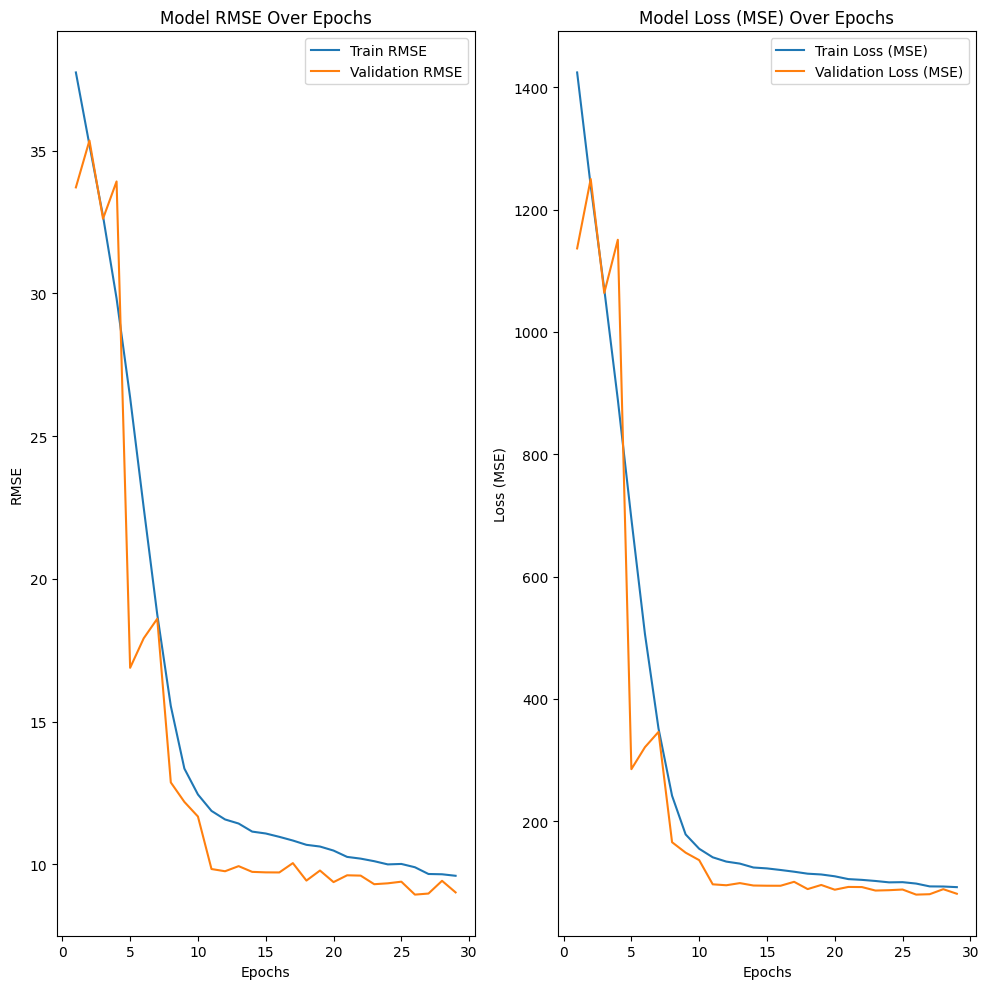

In [38]:
# Plot training and validation loss (MSE) and RMSE
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(10, 10))

# Plot training and validation RMSE
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["root_mean_squared_error"], label="Train RMSE")
plt.plot(epochs, history.history["val_root_mean_squared_error"], label="Validation RMSE")
plt.title("Model RMSE Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.legend()

# Plot training loss (MSE)
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history["loss"], label="Train Loss (MSE)")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss (MSE)")
plt.title("Model Loss (MSE) Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()

plt.tight_layout()
plt.show()

### Visualizing Random Test Images with True and Predicted Age
This code selects 20 random test images, displays them, and compares the true age labels with the predicted ages in a 5x4 grid of subplots.

149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


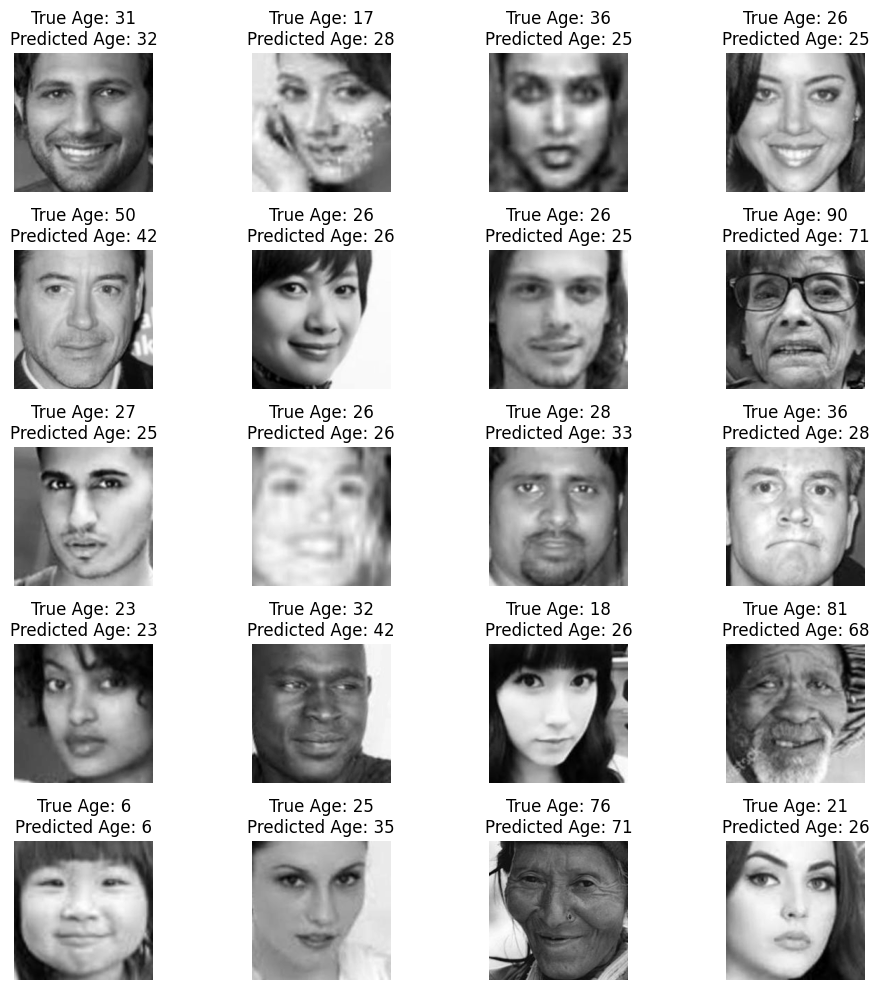

In [39]:
# Generate 20 random indices from the test set
random_indices = random.sample(range(X_test.shape[0]), 20)

# Predict the ages in the test set
y_pred = model.predict(X_test)  

# Define the class name for the plot
class_names = ["True Age"]  

# Set the figure size for the scatter plot
plt.figure(figsize=(10, 10))

for i, idx in enumerate(random_indices):  # Use the random indices
    plt.subplot(5, 4, i + 1)  # Create a 5x4 grid of subplots
    plt.imshow(X_test[idx].reshape(198, 198), cmap="gray")  # Display the image
    plt.title(f"True Age: {y_test[idx]}\nPredicted Age: {int(y_pred[idx][0])}")  # Set title with true and predicted age
    plt.axis("off")  # Turn off the axes

# Adjust layout for better visualization
plt.tight_layout()  
plt.show()